In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

df = pd.read_csv('./data/retailmax.csv')

In [5]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

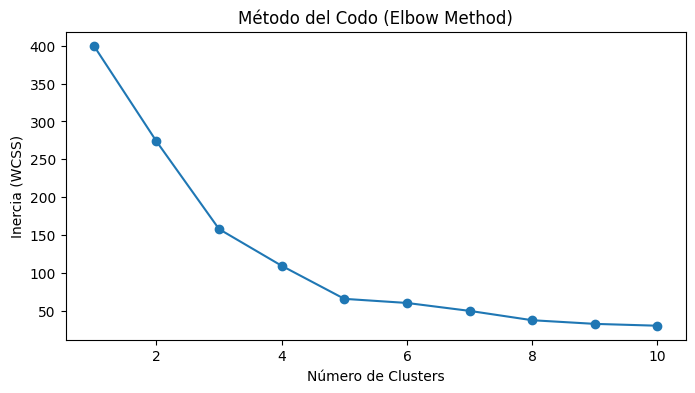

In [7]:
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(range(1, 11), wcss, marker='o')
plt.title('Método del Codo (Elbow Method)')
plt.xlabel('Número de Clusters')
plt.ylabel('Inercia (WCSS)')
plt.show()

In [8]:
model = KMeans(n_clusters=5, init='k-means++', random_state=42)
df['Cluster'] = model.fit_predict(X_scaled)

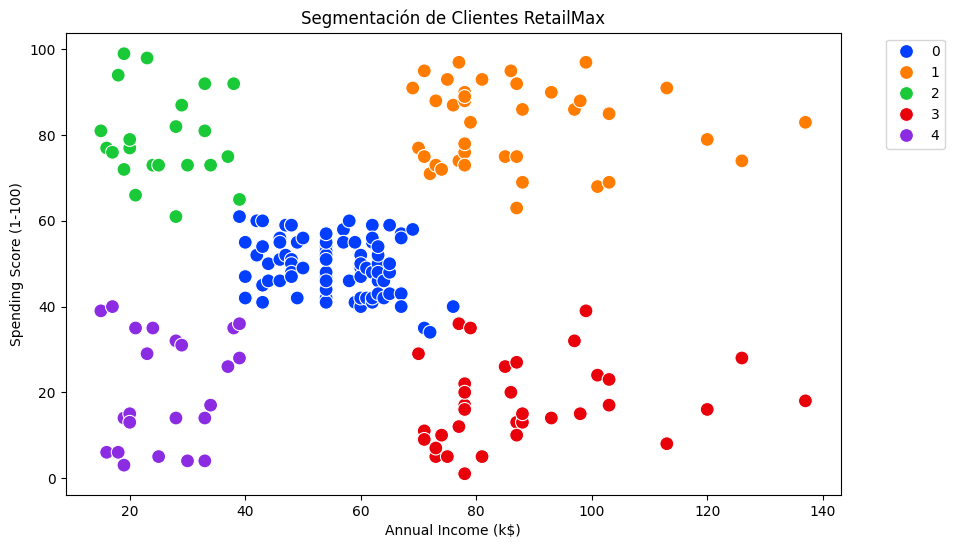

In [9]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)', 
                hue='Cluster', data=df, palette='bright', s=100)
plt.title('Segmentación de Clientes RetailMax')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2)
plt.show()